In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
##Load Data
indicators = pd.read_excel('../data/raw/climate_indicators.xls',sheet_name ='Data', engine = 'xlrd')
countries = pd.read_excel('../data/raw/climate_indicators.xls', sheet_name ='Country', engine = 'xlrd')

In [77]:
print("Indicator shape:",indicators.shape)
print("Countries shape:", countries.shape)
print("\nIndicator columns:", list(indicators.columns[:10]))
print("\nCountries columns:", list(countries.columns))


Indicator shape: (13512, 28)
Countries shape: (233, 6)

Indicator columns: ['Country code', 'Country name', 'Series code', 'Series name', 'SCALE', 'Decimals', 1990, 1991, 1992, 1993]

Countries columns: ['Country code', 'Country name', 'Capital city', 'Region', 'Income group', 'Lending category']


In [78]:
print(indicators['Series code'].unique())

['AG.LND.EL5M.ZS' 'AG.LND.IRIG.AG.ZS' 'AG.YLD.CREL.KG'
 'BX.KLT.DINV.WD.GD.ZS' 'EG.ELC.ACCS.ZS' 'EG.USE.COMM.GD.PP.KD'
 'EG.USE.PCAP.KG.OE' 'EN.ATM.CO2E.KT' 'EN.ATM.CO2E.PC'
 'EN.ATM.CO2E.PP.GD.KD' 'EN.ATM.GHGO.KT.CE' 'EN.ATM.METH.KT.CE'
 'EN.ATM.NOXE.KT.CE' 'EN.CLC.AERT' 'EN.CLC.DRSK.XQ' 'EN.CLC.GHGR.MT.CE'
 'EN.CLC.HCDM' 'EN.CLC.HJIP' 'EN.CLC.HPPT.MM' 'EN.CLC.ICER' 'EN.CLC.IERU'
 'EN.CLC.MDAT.ZS' 'EN.CLC.MMDT.C' 'EN.CLC.NAMA' 'EN.CLC.NAPA'
 'EN.CLC.NCOM' 'EN.CLC.PCAT.C' 'EN.CLC.PCCC' 'EN.CLC.PCHW'
 'EN.CLC.PCPT.MM' 'EN.CLC.RNET' 'EN.POP.EL5M.ZS' 'EN.URB.MCTY.TL.ZS'
 'ER.H2O.FWTL.ZS' 'ER.LND.PTLD.ZS' 'IC.BUS.EASE.XQ' 'IE.PPI.ENGY.CD'
 'IE.PPI.TELE.CD' 'IE.PPI.TRAN.CD' 'IE.PPI.WATR.CD' 'IQ.CPA.PUBS.XQ'
 'IS.ROD.PAVE.ZS' 'NY.GDP.MKTP.CD' 'NY.GNP.PCAP.CD' 'SE.ENR.PRSC.FM.ZS'
 'SE.PRM.CMPT.ZS' 'SH.DYN.MORT' 'SH.H2O.SAFE.ZS' 'SH.MED.NUMW.P3'
 'SH.MED.PHYS.ZS' 'SH.MLR.INCD' 'SH.STA.ACSN' 'SH.STA.MALN.ZS'
 'SI.POV.DDAY' 'SP.POP.GROW' 'SP.POP.TOTL' 'SP.URB.GROW' 'SP.URB.TOTL']


In [79]:
print(indicators['Series code'].nunique())

58


In [80]:
## Filtering data
# EN.ATM.CO2E.KT = total emissions, EN.ATM.CO2E.PC = per capita, NY.GDP.MKTP.CD = GDP, SP.POP.TOTL = population
keep = ['EN.ATM.CO2E.KT', 'EN.ATM.CO2E.PC', 'NY.GDP.MKTP.CD', 'SP.POP.TOTL']
co2_df = indicators[indicators['Series code'].isin(keep)]
print(co2_df.shape)
print(co2_df['Series code'].value_counts())

(932, 28)
Series code
EN.ATM.CO2E.KT    233
EN.ATM.CO2E.PC    233
NY.GDP.MKTP.CD    233
SP.POP.TOTL       233
Name: count, dtype: int64


In [81]:
print(co2_df[co2_df['Series code'] == 'EN.ATM.CO2E.KT'].head(3))

     Country code Country name     Series code                   Series name  \
1631          ABW        Aruba  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   
1632          ADO      Andorra  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   
1633          AFG  Afghanistan  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   

     SCALE Decimals      1990      1991      1992      1993  ...      2002  \
1631     0        1  1840.834  1928.842   1723.49  1771.161  ...  2255.205   
1632     0        1        ..        ..        ..        ..  ...   531.715   
1633     0        1   2676.91   2493.56  1426.463  1375.125  ...   359.366   

          2003      2004     2005     2006      2007      2008 2009 2010 2011  
1631  2255.205  2258.872  2273.54  2273.54  2357.881  2288.208   ..   ..   ..  
1632   535.382   564.718  575.719  546.383   539.049   539.049   ..   ..   ..  
1633   583.053   704.064  700.397   696.73   715.065   814.074   ..   ..   ..  

[3 rows x 28 columns]


In [82]:
print(countries['Region'].unique())

['Aggregates' 'Latin America & Caribbean' 'Europe & Central Asia'
 'South Asia' 'Sub-Saharan Africa' 'Middle East & North Africa'
 'East Asia & Pacific' 'North America']


In [83]:
## filter out where Region is equal to Aggregates
real_counires = countries[countries['Region'] != 'Aggregates']
print(real_counires.shape)
print(real_counires['Region'].unique())

(218, 6)
['Latin America & Caribbean' 'Europe & Central Asia' 'South Asia'
 'Sub-Saharan Africa' 'Middle East & North Africa' 'East Asia & Pacific'
 'North America']


In [91]:
merged_df = co2_df.merge(real_counires, on = 'Country code', how = 'inner')
print(merged_df.shape)
print(merged_df.columns.tolist())

(872, 33)
['Country code', 'Country name_x', 'Series code', 'Series name', 'SCALE', 'Decimals', 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 'Country name_y', 'Capital city', 'Region', 'Income group', 'Lending category']


In [92]:
merged_df = merged_df.drop(columns=['Country name_y', 'Capital city', 'Lending category'])
merged_df = merged_df.rename(columns = {'Country name_x' : 'Country name'})
print(merged_df.columns.tolist())

['Country code', 'Country name', 'Series code', 'Series name', 'SCALE', 'Decimals', 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 'Region', 'Income group']


In [93]:
year_cols = [col for col in merged_df.columns if isinstance(col, int)]
merged_df[year_cols] = merged_df[year_cols].replace('..',pd.NA)
print(merged_df[year_cols].isnull().sum().sum())

3191


In [94]:
merged_df[year_cols] = merged_df[year_cols].apply(pd.to_numeric, errors ='coerce')
#errors = 'coerce' if anything can't be converted to a number, make it NaN instead of crashing.
print(merged_df[year_cols].dtypes.unique())

[dtype('float64')]


In [95]:
print(merged_df[year_cols].isnull().sum(axis=1).describe())

count    872.000000
mean       3.659404
std        5.046266
min        1.000000
25%        1.000000
50%        3.000000
75%        3.000000
max       22.000000
dtype: float64


In [96]:
#unpvioting
#first dropping unwated col
merged_df = merged_df.drop(columns=['SCALE', 'Decimals'])
id_cols = ['Country code', 'Country name', 'Series code', 'Series name', 'Region', 'Income group']
melted_df = pd.melt(merged_df,id_vars=id_cols,var_name = 'Year', value_name='Value')
print(melted_df.shape)
print(melted_df.head())
print(melted_df.dtypes)

(19184, 8)
  Country code Country name     Series code                   Series name  \
0          ABW        Aruba  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   
1          ADO      Andorra  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   
2          AFG  Afghanistan  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   
3          AGO       Angola  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   
4          ALB      Albania  EN.ATM.CO2E.KT  CO2 emissions, total (KtCO2)   

                      Region          Income group  Year     Value  
0  Latin America & Caribbean  High income: nonOECD  1990  1840.834  
1      Europe & Central Asia  High income: nonOECD  1990       NaN  
2                 South Asia            Low income  1990  2676.910  
3         Sub-Saharan Africa   Lower middle income  1990  4429.736  
4      Europe & Central Asia   Upper middle income  1990  7488.014  
Country code     object
Country name     object
Series code      object
Series name      object
Region          

In [97]:
melted_df['Year'] = melted_df['Year'].astype(int)
print(melted_df.dtypes)
print(melted_df['Year'].unique())

Country code     object
Country name     object
Series code      object
Series name      object
Region           object
Income group     object
Year              int64
Value           float64
dtype: object
[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011]


In [98]:
#saving clean data 
melted_df.to_csv('../data/processed/climate_clean.csv', index=False)

In [99]:
co2 = melted_df[melted_df['Series code'] == 'EN.ATM.CO2E.KT']
print(co2.shape)
print(co2['Region'].unique())

(4796, 8)
['Latin America & Caribbean' 'Europe & Central Asia' 'South Asia'
 'Sub-Saharan Africa' 'Middle East & North Africa' 'East Asia & Pacific'
 'North America']


In [101]:
region_year = (
    co2
    .groupby(['Region', 'Year'])['Value']
    .sum()
    .reset_index()
)
print(region_year.shape)
print(region_year.head(10))


(154, 3)
                Region  Year        Value
0  East Asia & Pacific  1990  4826556.738
1  East Asia & Pacific  1991  5048861.279
2  East Asia & Pacific  1992  5272977.318
3  East Asia & Pacific  1993  5539304.194
4  East Asia & Pacific  1994  5843723.866
5  East Asia & Pacific  1995  6196932.973
6  East Asia & Pacific  1996  6482368.586
7  East Asia & Pacific  1997  6561902.149
8  East Asia & Pacific  1998  6053410.260
9  East Asia & Pacific  1999  6128437.080


In [105]:
pivot = co2.pivot_table(
    index = 'Region',
    columns = 'Year',
    values = 'Value',
    aggfunc = 'sum'
)
pivot

Year,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
Region,,,,,,,,,,,,,,,,,,,,,
East Asia & Pacific,4826556.738,5048861.279,5272977.318,5539304.194,5843723.866,6196932.973,6482368.586,6561902.149,6053410.260,6128437.080,...,6760110.833,7674330.603,8565239.254,9092942.556,9697960.886,1.018852e+07,1.049195e+07,0.0,0.0,0.0
Europe & Central Asia,3171401.283,4199441.066,7842598.232,7404215.716,6934212.659,6916306.698,6956687.702,6678003.036,6625165.233,6445174.205,...,6565829.506,6762798.744,6811489.170,6857561.358,6976229.145,6.983857e+06,6.982272e+06,0.0,0.0,0.0
Latin America & Caribbean,1008307.656,1027302.716,1048450.305,1078035.661,1129223.314,1155105.000,1199765.393,1254499.035,1304267.559,1334226.949,...,1368682.081,1387864.158,1409000.746,1453602.467,1490536.491,1.558937e+06,1.640388e+06,0.0,0.0,0.0
Middle East & North Africa,948271.532,1010005.477,1092964.018,1158276.955,1246314.291,1211136.760,1206208.312,1195100.969,1294964.380,1309929.407,...,1491618.256,1632247.706,1717498.122,1809033.776,1899223.641,1.953279e+06,2.072552e+06,0.0,0.0,0.0
North America,5330050.506,5319801.241,5344062.113,5645885.549,5682141.178,5698224.640,5811872.304,5985075.715,5928420.565,6006512.997,...,5960173.118,6025742.745,6120336.677,6158598.155,6064000.556,6.126226e+06,6.005494e+06,0.0,0.0,0.0
South Asia,782042.755,829911.773,882456.216,917861.101,977600.198,1036972.595,1131962.563,1175882.222,1205405.239,1283446.333,...,1389855.339,1449891.463,1534610.164,1602354.322,1713919.130,1.838124e+06,1.970176e+06,0.0,0.0,0.0
Sub-Saharan Africa,460468.857,468605.930,472052.910,490732.608,493310.509,487157.283,502265.323,512631.932,509206.954,517032.332,...,558531.771,584673.814,637518.951,644918.957,638230.349,6.714754e+05,6.847242e+05,0.0,0.0,0.0


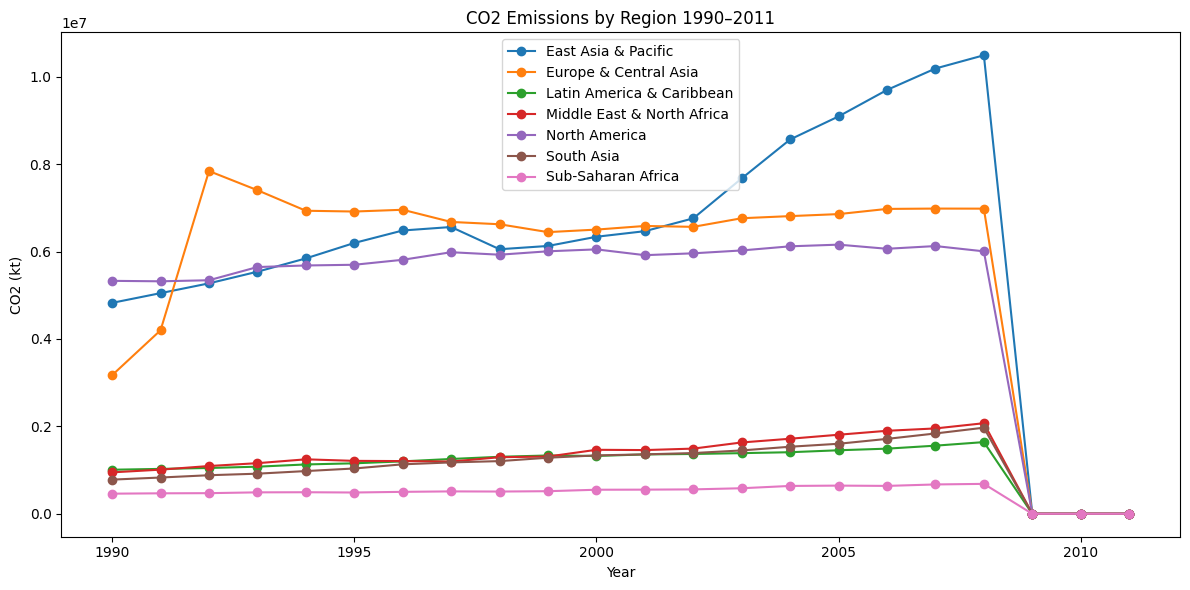

In [106]:
fig, ax = plt.subplots(figsize=(12,6))
for region in region_year['Region'].unique():
    data = region_year[region_year['Region'] == region]
    ax.plot(data['Year'],data['Value'], marker = 'o', label =region)
ax.set_title('CO2 Emissions by Region 1990–2011')
ax.set_xlabel('Year')
ax.set_ylabel('CO2 (kt)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/co2_by_region.png', dpi=150)
plt.show()

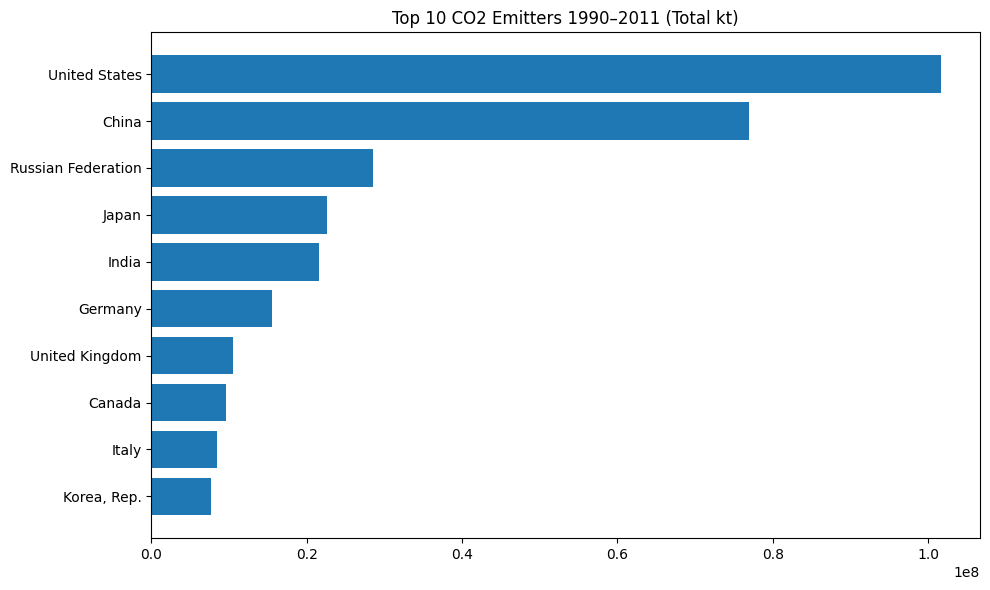

In [107]:
top10 = (
    co2.groupby('Country name')['Value']
    .sum()
    .nlargest(10)
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(top10['Country name'], top10['Value'])
ax.set_title('Top 10 CO2 Emitters 1990–2011 (Total kt)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/top10_emitters.png', dpi=150)
plt.show()

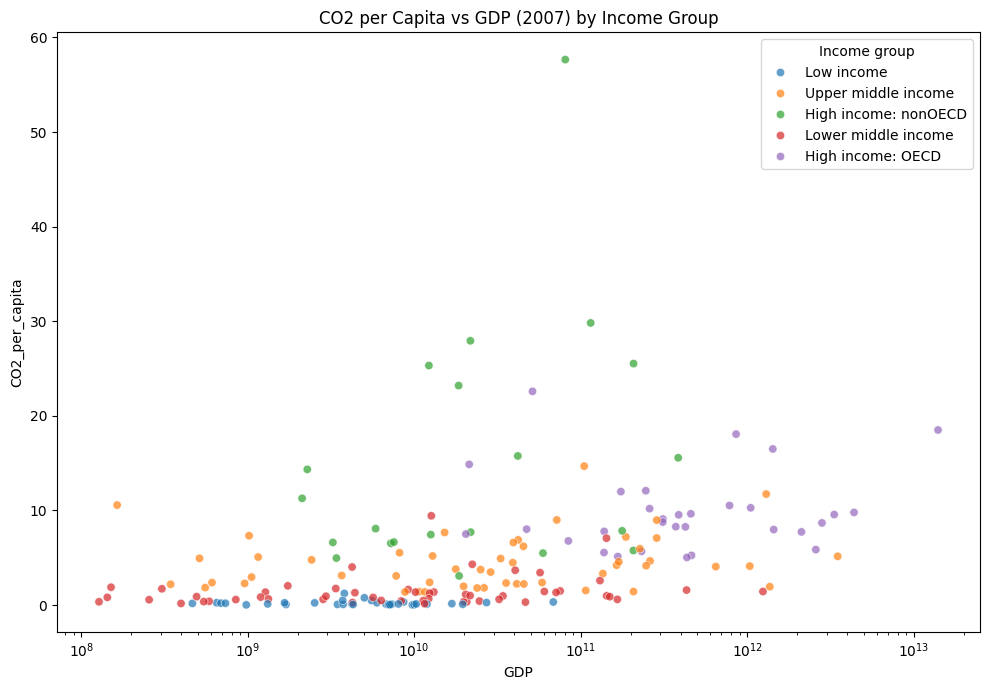

In [112]:
import seaborn as sns

co2_gdp = melted_df[melted_df['Series code'].isin(['EN.ATM.CO2E.PC', 'NY.GDP.MKTP.CD'])]

co2_gdp_pivot = co2_gdp.pivot_table(
    index=['Country name', 'Income group', 'Year'],
    columns='Series code',
    values='Value'
).reset_index()

co2_gdp_pivot.columns.name = None
co2_gdp_pivot = co2_gdp_pivot.rename(columns={
    'EN.ATM.CO2E.PC': 'CO2_per_capita',
    'NY.GDP.MKTP.CD': 'GDP'
}).dropna()

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=co2_gdp_pivot[co2_gdp_pivot['Year'] == 2007],
    x='GDP', y='CO2_per_capita',
    hue='Income group', alpha=0.7, ax=ax
)
ax.set_xscale('log')
ax.set_title('CO2 per Capita vs GDP (2007) by Income Group')
plt.tight_layout()
plt.savefig('../outputs/co2_vs_gdp_scatter.png', dpi=150)
plt.show()